## Datasets for DA

* Original Explanations
* Cleaned Explanations

**Each with token counts depending on model's tokenizer**

In [58]:
import yaml
import json
import os
from collections import defaultdict
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer

with open('../models/model_config.yaml', 'r') as f:
    model_config = yaml.load(f, Loader=yaml.FullLoader)

SAVE_DIR = 'final_data_attn'
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

## Original Explanations

In [54]:
def load_data(data_path):
    with open(data_path, 'r') as f:
        lines = f.read().strip().split('\n')
        data = [json.loads(line.strip()) for line in lines if line]
    return data


train_data = load_data('raw_baseline/train.jsonl')
print(f'total train entries: {len(train_data)}')

dev_data = load_data('raw_baseline/dev.jsonl')
print(f'total dev entries: {len(dev_data)}')

total train entries: 182822
total dev entries: 4183


In [55]:
df_train = {'entries': [entry['exp'] for entry in train_data if entry is not None and entry['exp'] is not None]}
df_val = {'entries': [entry['exp'] for entry in dev_data if entry is not None and entry['exp'] is not None]}

TRAIN_CORPUS = "\n".join(df_train['entries'])
DEV_CORPUS = "\n".join(df_val['entries'])

corpus_sizes = defaultdict(lambda: defaultdict(int))

for _, checkpoint in tqdm(model_config.items(), desc='Converting datasets to tokens'):
    print(f'processing {checkpoint}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)

    train_tokens = len(tokenizer(TRAIN_CORPUS).input_ids)
    dev_tokens = len(tokenizer(DEV_CORPUS).input_ids)
    corpus_sizes[checkpoint]['train'] = train_tokens
    corpus_sizes[checkpoint]['dev'] = dev_tokens


Converting datasets to tokens:   0%|          | 0/4 [00:00<?, ?it/s]

processing FacebookAI/roberta-large


Token indices sequence length is longer than the specified maximum sequence length for this model (20886869 > 512). Running this sequence through the model will result in indexing errors
Converting datasets to tokens:  25%|██▌       | 1/4 [00:41<02:05, 41.80s/it]

processing google/bigbird-roberta-large


Token indices sequence length is longer than the specified maximum sequence length for this model (20700074 > 4096). Running this sequence through the model will result in indexing errors
Converting datasets to tokens:  50%|█████     | 2/4 [01:21<01:20, 40.28s/it]

processing allenai/longformer-large-4096


Converting datasets to tokens:  75%|███████▌  | 3/4 [02:01<00:40, 40.29s/it]

processing answerdotai/ModernBERT-large


Token indices sequence length is longer than the specified maximum sequence length for this model (19801098 > 8192). Running this sequence through the model will result in indexing errors
Converting datasets to tokens: 100%|██████████| 4/4 [02:40<00:00, 40.23s/it]


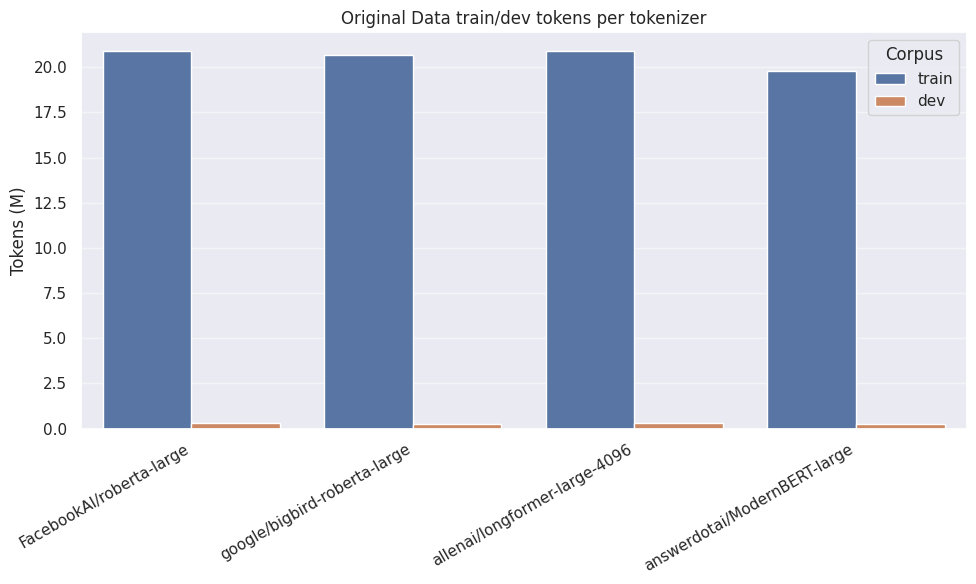

In [60]:
rows = []
for model, train_dev in corpus_sizes.items():
    for train_or_dev, num_tokens in train_dev.items():
        rows.append({
            "Model": model,
            "Corpus": train_or_dev,
            "Tokens (M)": num_tokens / 1_000_000
        })

df_vis = pd.DataFrame(rows)
sns.set_theme()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_vis,
    x="Model",
    y="Tokens (M)",
    hue="Corpus"
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Tokens (M)")
plt.xlabel("")
plt.title("Original Data train/dev tokens per tokenizer")

plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.1f}")

plt.tight_layout()
plt.show()

In [61]:
ORIGINAL_SAVE_DIR = os.path.join(SAVE_DIR, 'original_corpus')

if not os.path.exists(ORIGINAL_SAVE_DIR):
    os.makedirs(ORIGINAL_SAVE_DIR)

df_train = pd.DataFrame(df_train)
df_train.to_csv(os.path.join(ORIGINAL_SAVE_DIR, 'train.csv'), index=False)

df_val = pd.DataFrame(df_val)
df_val.to_csv(os.path.join(ORIGINAL_SAVE_DIR, 'dev.csv'), index=False)

## Cleaned Explanations